Metabolomic Signatures of Kidney Dysfunction

Research Question: Which metabolites are significantly altered during kidney transplant rejection & could they be used to classify samples in rejection vs. non-rejection states?

Data Sources: Metabolomics Workbench (ST000342)

Project Name: Renal metabolic pathways indicating ischemic or inflammatory changes
Data type: LC-MS metabolomics of renal tissue samples under different perfusion conditions.


Setup & Imports
Standard libraries for data manipulation (pandas, numpy), statistical testing (scipy), dimensionality reduction (sklearn), and visualization (matplotlib, seaborn).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from statsmodels.stats.multitest import multipletests

import seaborn as sns

Data Loading & Cleaning
Dataset ST000342 from Metabolomics Workbench. LC-MS metabolomics of renal tissue samples perfused under two conditions: Whole Blood vs. Packed Red Blood Cell (pRBC) perfusate. Metabolite names are set as the index and all values are coerced to numeric.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving MSdata_ST000342_1.txt to MSdata_ST000342_1 (2).txt


In [ ]:
data = pd.read_csv("MSdata_ST000342_1.txt", sep="\t")
data.head(15)

,Metabolite_name,RefMet_name,Biorec02_Palma,Biorec03_Palma,Biorec04_Palma,Palm16 _8B_T2_004,Palm21 _9B_T1_007,Palm22 _9B_T2_008,Palm26 _8B_T1_003,Palm27 _11B_T2_016,...,Palm11 _9A_T1_005,Palm13 _10A_T1_009,Palm14 _29_T6_018,Palm17 _9A_T2_006,Palm18 _11A_T2_014,Palm20 _10A_T2_010,Palm25 _8A_T1_001,Palm28 _8A_T2_002,Palm31 _29_T0_017,Palm36 _11A_T1_013
0,Factors,-,Organ:Plasma | Treatment:Quality Control,Organ:Plasma | Treatment:Quality Control,Organ:Plasma | Treatment:Quality Control,Organ:Renal Tissue | Treatment:PRBC,Organ:Renal Tissue | Treatment:PRBC,Organ:Renal Tissue | Treatment:PRBC,Organ:Renal Tissue | Treatment:PRBC,Organ:Renal Tissue | Treatment:PRBC,...,Organ:Renal Tissue | Treatment:WB,Organ:Renal Tissue | Treatment:WB,Organ:Renal Tissue | Treatment:WB,Organ:Renal Tissue | Treatment:WB,Organ:Renal Tissue | Treatment:WB,Organ:Renal Tissue | Treatment:WB,Organ:Renal Tissue | Treatment:WB,Organ:Renal Tissue | Treatment:WB,Organ:Renal Tissue | Treatment:WB,Organ:Renal Tissue | Treatment:WB
1,1_iSTD PG (17:0/17:0),Standard,483445,510362,521211,503635,462471,390555,515357,374722,...,435312,473752,496799,457308,402071,449168,403434,495541,471204,519026
2,Ceramide (d32:1),Cer 32:1;O2,952,830,834,7058,7955,6617,7063,3972,...,6207,4759,16315,7767,4468,4778,7647,9478,13391,5702
3,Ceramide (d33:1),Cer 33:1;O2,1330,1409,1332,5494,7425,6003,6077,3916,...,5705,3838,5062,7258,4351,4041,7453,7723,5510,5337
4,Ceramide (d34:0),Cer 34:0;O2,1762,1340,1463,5364,12153,11564,5584,8363,...,11642,4923,8903,12723,6426,7008,6853,9000,7242,5963
5,Ceramide (d34:1),Cer 34:1;O2,10271,10616,10390,96786,110416,120987,91911,76523,...,101818,108193,120335,115839,77899,102200,122076,123511,141081,83421
6,Ceramide (d34:2),Cer 34:2;O2,647,744,662,5784,8069,9992,5578,4554,...,7561,7553,8252,8304,4726,6560,7917,8310,10166,5101
7,Ceramide (d36:1),Cer 36:1;O2,2876,2713,2825,35086,26162,19552,40089,17821,...,16906,31943,41000,28108,23607,34477,36179,44967,38247,28575
8,Ceramide (d38:1),Cer 38:1;O2,2455,2411,2645,33603,15524,11284,37259,16142,...,11572,28272,51255,17724,22095,36791,30585,39680,33025,27020
9,Ceramide (d39:1),Cer 39:1;O2,1176,1001,1329,4698,1805,1503,5132,1887,...,2104,2255,5163,2319,2462,3480,4769,6388,3105,3913


In [ ]:
data = data.drop(index=0)
data.head()

,Metabolite_name,RefMet_name,Biorec02_Palma,Biorec03_Palma,Biorec04_Palma,Palm16 _8B_T2_004,Palm21 _9B_T1_007,Palm22 _9B_T2_008,Palm26 _8B_T1_003,Palm27 _11B_T2_016,...,Palm11 _9A_T1_005,Palm13 _10A_T1_009,Palm14 _29_T6_018,Palm17 _9A_T2_006,Palm18 _11A_T2_014,Palm20 _10A_T2_010,Palm25 _8A_T1_001,Palm28 _8A_T2_002,Palm31 _29_T0_017,Palm36 _11A_T1_013
1,1_iSTD PG (17:0/17:0),Standard,483445,510362,521211,503635,462471,390555,515357,374722,...,435312,473752,496799,457308,402071,449168,403434,495541,471204,519026
2,Ceramide (d32:1),Cer 32:1;O2,952,830,834,7058,7955,6617,7063,3972,...,6207,4759,16315,7767,4468,4778,7647,9478,13391,5702
3,Ceramide (d33:1),Cer 33:1;O2,1330,1409,1332,5494,7425,6003,6077,3916,...,5705,3838,5062,7258,4351,4041,7453,7723,5510,5337
4,Ceramide (d34:0),Cer 34:0;O2,1762,1340,1463,5364,12153,11564,5584,8363,...,11642,4923,8903,12723,6426,7008,6853,9000,7242,5963
5,Ceramide (d34:1),Cer 34:1;O2,10271,10616,10390,96786,110416,120987,91911,76523,...,101818,108193,120335,115839,77899,102200,122076,123511,141081,83421


In [ ]:
data = data.set_index(" Metabolite_name")
data = data.drop(columns=["RefMet_name"])
data = data.apply(pd.to_numeric, errors="coerce")
data.head()

,Biorec02_Palma,Biorec03_Palma,Biorec04_Palma,Palm16 _8B_T2_004,Palm21 _9B_T1_007,Palm22 _9B_T2_008,Palm26 _8B_T1_003,Palm27 _11B_T2_016,Palm32 _11B_T1_015,Palm33 _10B_T2_012,...,Palm11 _9A_T1_005,Palm13 _10A_T1_009,Palm14 _29_T6_018,Palm17 _9A_T2_006,Palm18 _11A_T2_014,Palm20 _10A_T2_010,Palm25 _8A_T1_001,Palm28 _8A_T2_002,Palm31 _29_T0_017,Palm36 _11A_T1_013
Metabolite_name,,,,,,,,,,,,,,,,,,,,,
1_iSTD PG (17:0/17:0),483445.0,510362.0,521211.0,503635.0,462471.0,390555.0,515357.0,374722.0,427803.0,405776.0,...,435312.0,473752.0,496799.0,457308.0,402071.0,449168.0,403434.0,495541.0,471204.0,519026.0
Ceramide (d32:1),952.0,830.0,834.0,7058.0,7955.0,6617.0,7063.0,3972.0,5469.0,4246.0,...,6207.0,4759.0,16315.0,7767.0,4468.0,4778.0,7647.0,9478.0,13391.0,5702.0
Ceramide (d33:1),1330.0,1409.0,1332.0,5494.0,7425.0,6003.0,6077.0,3916.0,4731.0,3810.0,...,5705.0,3838.0,5062.0,7258.0,4351.0,4041.0,7453.0,7723.0,5510.0,5337.0
Ceramide (d34:0),1762.0,1340.0,1463.0,5364.0,12153.0,11564.0,5584.0,8363.0,6874.0,9141.0,...,11642.0,4923.0,8903.0,12723.0,6426.0,7008.0,6853.0,9000.0,7242.0,5963.0
Ceramide (d34:1),10271.0,10616.0,10390.0,96786.0,110416.0,120987.0,91911.0,76523.0,88990.0,107264.0,...,101818.0,108193.0,120335.0,115839.0,77899.0,102200.0,122076.0,123511.0,141081.0,83421.0


Sample Group Assignment
Samples are labeled by perfusate condition: Whole Blood vs. Packed RBC. These conditions model differential levels of ischemic and inflammatory stress in renal tissue, serving as a proxy for metabolic states relevant to transplant rejection risk.

In [ ]:
sample_names = data.columns
group_labels = []

for col in sample_names:
    if "Palma" in col:
        group_labels.append("WholeBlood_Perfusion")
    else:
        group_labels.append("PackedRBC_Perfusion")

sample_metadata = pd.DataFrame({"Sample": sample_names, "Group": group_labels})
sample_metadata

,Sample,Group
0,Biorec02_Palma,WholeBlood_Perfusion
1,Biorec03_Palma,WholeBlood_Perfusion
2,Biorec04_Palma,WholeBlood_Perfusion
3,Palm16 _8B_T2_004,PackedRBC_Perfusion
4,Palm21 _9B_T1_007,PackedRBC_Perfusion
5,Palm22 _9B_T2_008,PackedRBC_Perfusion
6,Palm26 _8B_T1_003,PackedRBC_Perfusion
7,Palm27 _11B_T2_016,PackedRBC_Perfusion
8,Palm32 _11B_T1_015,PackedRBC_Perfusion
9,Palm33 _10B_T2_012,PackedRBC_Perfusion


Preprocessing
Data is log2-transformed to reduce skewness, missing values are imputed with column medians, and features are standardized (z-score) prior to PCA.

In [ ]:
data_log = np.log2(data + 1)
data_transposed = data_log.T
data_transposed.columns = data_transposed.columns.astype(str)
data_transposed = data_transposed.dropna(axis=1, how='all')
data_transposed = data_transposed.apply(lambda col: col.fillna(col.median()), axis=0)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_transposed)

Dimensionality Reduction — PCA
Principal Component Analysis visualizes global metabolic differences between perfusate groups across all samples.

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

In [ ]:
pca_data = pd.DataFrame({"PC1": pca_result[:, 0], "PC2": pca_result[:, 1], "Group": sample_metadata["Group"].values, "Sample": sample_metadata["Sample"].values})

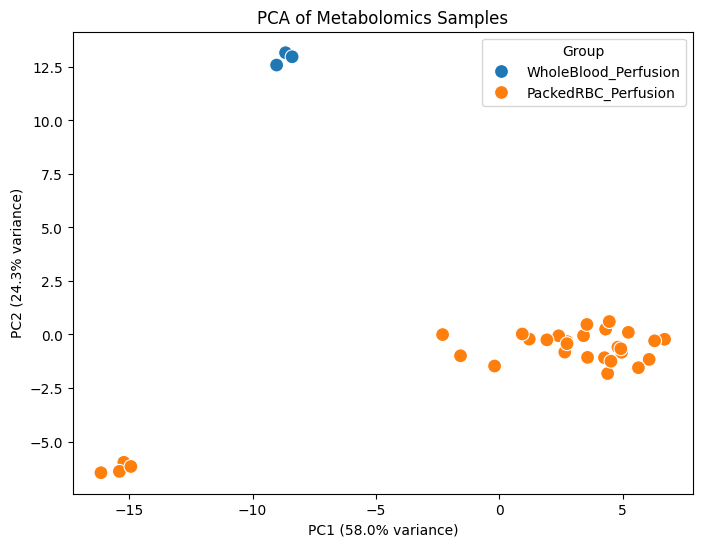

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot( data=pca_data, x="PC1", y="PC2", hue="Group", s=100)

plt.title("PCA of Metabolomics Samples")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.show()

In [ ]:
group_series = sample_metadata.set_index("Sample")["Group"]

group1 = group_series[group_series == "WholeBlood_Perfusion"].index
group2 = group_series[group_series == "PackedRBC_Perfusion"].index

print("WholeBlood:", len(group1))
print("PackedRBC:", len(group2))

WholeBlood: 3
PackedRBC: 30


PCA revealed a clear separation between whole blood and packed RBC perfusion groups along PC1 (58.0% variance) and PC2 (24.3% variance), capturing over 82% of total metabolic variation. Whole blood samples cluster tightly together while packed RBC samples show greater dispersion, suggesting that perfusate composition is the dominant driver of global metabolic differences and that packed RBC perfusion may induce more variable ischemic stress across individual kidneys.

Differential Metabolite Analysis
Welch's t-test (unequal variance assumed) identifies metabolites significantly different between perfusate groups. A p-value threshold of 0.05 is applied.

In [ ]:
results = []

for metabolite in data_log.index:
    vals1 = data_log.loc[metabolite, group1].dropna()
    vals2 = data_log.loc[metabolite, group2].dropna()

    if len(vals1) < 2 or len(vals2) < 2:
        continue

    stat, pval = ttest_ind(vals1, vals2, equal_var=False)

    mean1 = vals1.mean()
    mean2 = vals2.mean()

    if mean1 > 0 and mean2 > 0:
        fold_change = np.log2(mean2 / mean1)
    else:
        fold_change = np.nan

    results.append([metabolite, mean1, mean2, fold_change, pval])

results_data = pd.DataFrame(results, columns=["Metabolite", "Mean_WholeBlood", "Mean_PackedRBC", "Log2_FoldChange", "P_Value"])
results_data = results_data.dropna(subset=["Log2_FoldChange"])
results_data = results_data.sort_values("P_Value")

print("Total metabolites tested:", len(results_data))
print("Significant (p<0.05):", (results_data["P_Value"] < 0.05).sum())
print("Min p-value:", results_data["P_Value"].min())
results_data.head(10)

Total metabolites tested: 84
Significant (p<0.05): 71
Min p-value: 4.854291780180785e-28


,Metabolite,Mean_WholeBlood,Mean_PackedRBC,Log2_FoldChange,P_Value
58,PE (38:4),12.613818,17.894295,0.504495,4.854292e-28
53,PE (34:1),9.830000,14.833638,0.593609,7.304731e-27
57,PE (36:4),11.211524,16.305322,0.540360,3.222666e-26
60,PE (p-34:1) or PE (o-34:2),9.825334,14.105923,0.521723,2.066573e-25
56,PE (36:3),10.187012,14.674635,0.526594,4.310921e-25
63,PE (p-36:4) or PE (o-36:5),13.320687,17.677684,0.408261,9.465264e-25
37,LPC (16:0),16.304910,11.328718,-0.525322,1.977976e-23
6,Ceramide (d36:1),11.453700,14.691485,0.359167,2.835653e-23
55,PE (36:2),12.190130,15.549042,0.351112,1.743723e-21
4,Ceramide (d34:1),13.347855,16.559863,0.311083,9.133492e-21


In [ ]:
results_data["Significant"] = results_data["P_Value"] < 0.05

Volcano Plot
Visualizes effect size (log2 fold change) vs. statistical significance (-log10 p-value). Points above the dashed line are statistically significant.

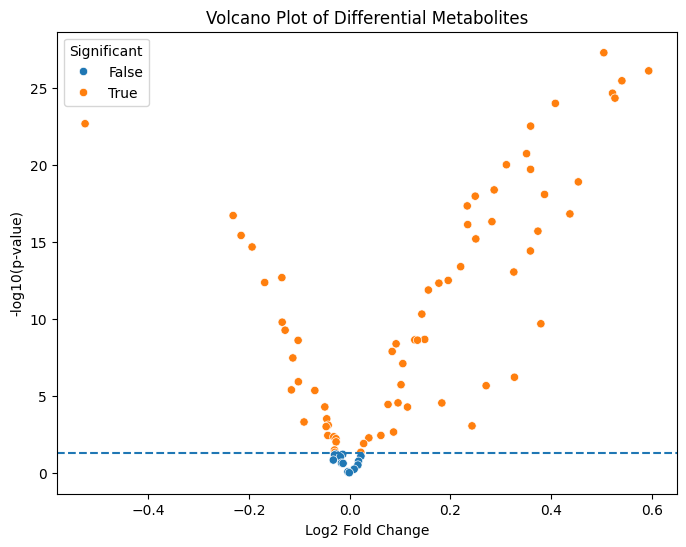

In [ ]:
plt.figure(figsize=(8,6))
results_data["neg_log10_p"] = -np.log10(results_data["P_Value"])
sns.scatterplot(data = results_data, x = "Log2_FoldChange", y = "neg_log10_p", hue = "Significant")

plt.axhline(-np.log10(0.05), linestyle="--")

plt.title("Volcano Plot of Differential Metabolites")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(p-value)")

plt.show()

Welch's t-test identified a substantial number of significantly altered metabolites between perfusate groups (p < 0.05), shown as orange points above the dashed threshold line. The rightward skew indicates that most significant metabolites are more abundant under packed RBC perfusion conditions, while a smaller subset is higher in whole blood, suggesting bidirectional and complex metabolic remodeling between the two conditions.

Heatmap — Top 20 Differential Metabolites
Expression patterns of the top 20 most significantly altered metabolites across all samples (log2 intensity).

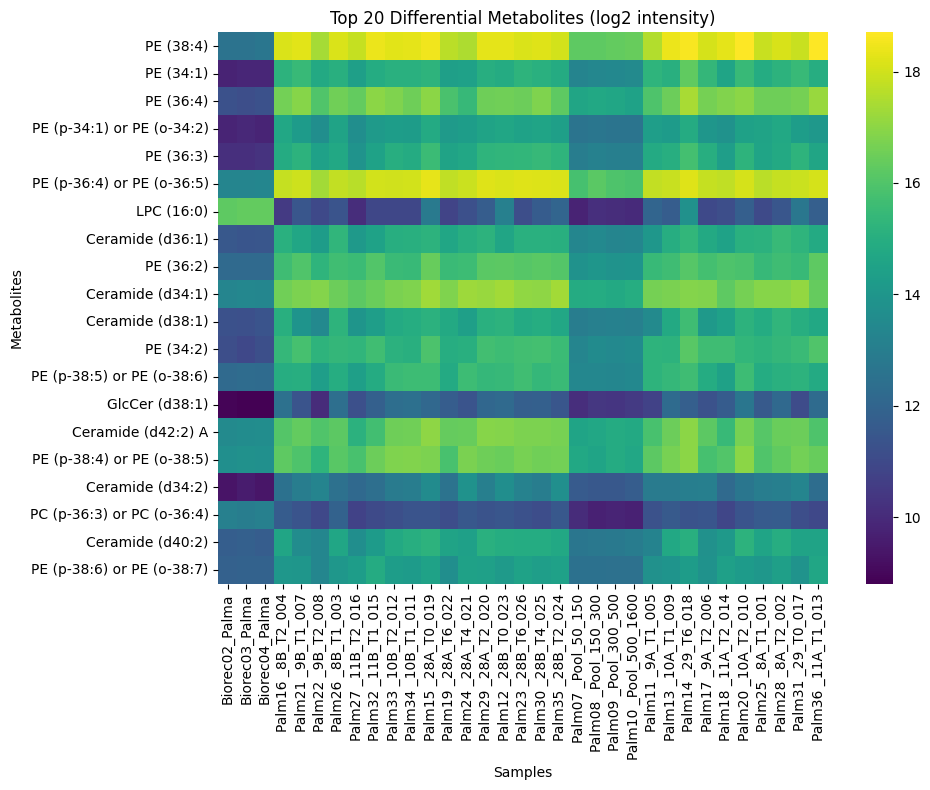

In [ ]:
top_mets = results_data.nsmallest(20, "P_Value")["Metabolite"]

heatmap_data = data_log.loc[top_mets]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap="viridis", xticklabels=True, yticklabels=True)

plt.title("Top 20 Differential Metabolites (log2 intensity)")
plt.xlabel("Samples")
plt.ylabel("Metabolites")
plt.tight_layout()
plt.show()

The top 20 most significantly altered metabolites are dominated by phosphatidylethanolamine (PE) species and ceramides. PE dysregulation reflects compromised membrane integrity, while ceramide accumulation is a known mediator of apoptosis and inflammation during ischemic stress. LPC(16:0) further indicates phospholipid membrane breakdown. Together these lipid signatures form a coherent molecular fingerprint of ischemia-induced cellular stress.



**Conclusions:**

**Findings:** PCA and differential metabolite analysis show that perfusate composition (whole blood vs. packed red blood cells) produces clearly different metabolic profiles in renal tissue. This directly suggests that metabolomic profiling of renal tissue under ischemic perfusion conditions could potentially be used to identify biomarkers of cellular stress relevant to kidney transplant rejection. The metabolites that changed the most were mainly phosphatidylethanolamines, ceramides, and LPC(16:0). This points to a pattern of cellular stress and membrane damage that mirrors what happens during transplant rejection.

**Significance:** These findings support the feasibility of using LC-MS metabolomics to classify kidney samples based on perfusate-induced metabolic stress, with potential clinical relevance for non-invasive monitoring of transplant rejection risk via lipid biomarker panels.

**Key Limitations:** The findings were obtained with no FDR (false discovery rate) correction applied to the statistical tests. That suggests that out of all flagged metabolites, a small number could be false positive by chance, not actually carrying any significance.
This is something to be considered and addressed before making firm conclusions and proceeding with further research.
Additionally, perfusate condition (whole blood vs. pRBC) serves as a proxy for transplant rejection stress, not a direct comparison of rejecting vs. non-rejecting patient tissue. The identified metabolites reflect  experimentally-induced differences, and their translational validity as true rejection biomarkers requires validation in clinical samples from transplant patients.

**Future Direction:** The metabolomic pipeline should be applied to matched pre- and post-rejection samples from transplant recipients, combined with FDR correction and pathway enrichment analysis. This would help determine if PE/ceramide signatures identified in this project were recapitulated in clinically true rejection contexts to support diagnostic model development later on.